## ICP Problem formulation 

<img src="data/ab.png" width=600>


$$\text{Given 2 point clouds} \quad $$

$$
A = 
\begin{bmatrix} 
    x_0 & x_1 & \cdot\cdot\cdot & x_N \\ 
    y_0 & y_1 & \cdot\cdot\cdot & x_N \\ 
\end{bmatrix}, \quad 
B = 
\begin{bmatrix} 
    u_0 & u_1 & \cdot\cdot\cdot & u_M \\ 
    v_0 & u_2 & \cdot\cdot\cdot & u_M \\ 
\end{bmatrix}
\\ 
$$

$$\text{Find motion function } \space (R, t) \space \text{s.t.} \quad 

\begin{bmatrix} 
    x_i \\ 
    y_i \\
\end{bmatrix} 
= 
R 
\begin{bmatrix} 
    u_j \\ 
    v_j  \\ 
\end{bmatrix} + t

\text{ is most consistent for all } i = 0, 1, ...,N
$$

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

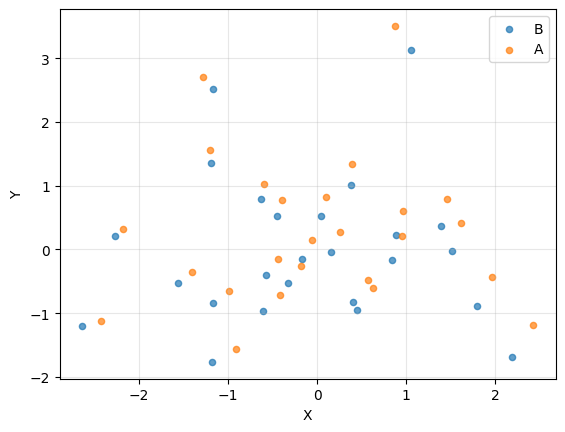

In [19]:
# Load point-cloud data from a.npy and b.npy files
A = np.load("data/a.npy")
B = np.load("data/b.npy")

def plot_points(A, B, Ahat=None):
    x, y = B
    plt.scatter(x, y, s=20, alpha=0.7, label="B")

    x, y = A
    plt.scatter(x, y, s=20, alpha=0.7, label="A")
    
    if Ahat is not None:
        x, y = Ahat
        plt.scatter(x, y, s=8, alpha=0.9, label="C")
    
    plt.grid(True, alpha=0.3)
    plt.xlabel("X")
    plt.ylabel("Y")
    plt.legend()
    plt.show()

plot_points(A, B)

### Classic 2D rigid alignment problem

Given two corresponding 2D point sets, find the rotation $𝑅 ∈ 𝑆𝑂(2)$,  and translation $ 𝑡 \in 𝑅^2$ that best aligns them in the least-squares sense.

Given: 
$$
A =
\begin{bmatrix} 
    a_1, \cdot\cdot\cdot, a_N 
\end{bmatrix}, 
B = 
\begin{bmatrix} 
    b_1, \cdot\cdot\cdot, b_N 
\end{bmatrix}, a_i, b_i \in R^2 \\ 
$$

We want 
$$
\hat{R}, \hat{t} = \min_{R, t} \sum_{i=1}^{N} {||a_i - (R b_i + t)||^2} \\
            \text {s.t.} \quad R^T R = I \\
             \det(R) = 1
$$


Assummtion: 
- Points are in correct correspondence: A[:, i] matches B[:, i]
- No strong outliers. One bad point can skew SVD 

Globally optimal rigid motion:

<img src="i/icp_sln.png" width=600>

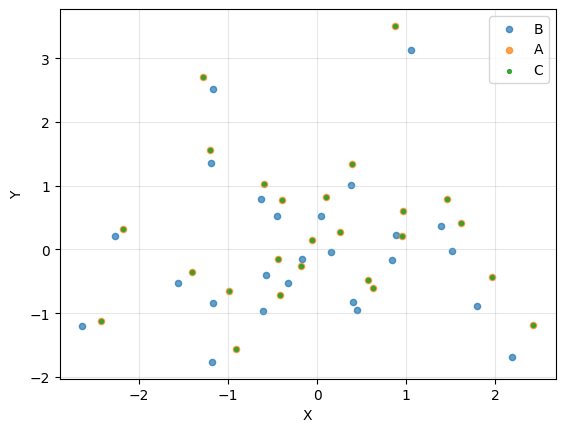

In [23]:
import numpy as np
def rigid_align(A, B):
    Ac = A.mean(axis=1, keepdims=True)
    Bc = B.mean(axis=1, keepdims=True)

    A0 = A - Ac
    B0 = B - Bc

    H = B0 @ A0.T
    U, _, Vt = np.linalg.svd(H)
    R = Vt.T @ U.T

    if np.linalg.det(R) < 0:
        Vt[-1,:] *= -1
        R = Vt.T @ U.T
    
    t = Ac - R @ Bc
    return R, t

R_hat, t_hat = rigid_align(A, B)
Ahat = R_hat @ B + t_hat
plot_points(A, B, Ahat)

In [24]:
R = np.load("data/r.npy")
t = np.load("data/t.npy")
print(f"R_hat vs R: \n {R_hat} \n\n {R}")
print(f"t_hat vs t: \n {t_hat} \n\n {t}")

R_hat vs R: 
 [[ 0.9961947  -0.08715574]
 [ 0.08715574  0.9961947 ]] 

 [[ 0.9961947  -0.08715574]
 [ 0.08715574  0.9961947 ]]
t_hat vs t: 
 [[0.1]
 [0.3]] 

 [0.1 0.3]
